In [1]:
FINAL_BS = 512
LOG_PATH = "../scripts/lp_evaluation_log.json"
LOSSES_PATH = "/exp_local/kenzosaki/models/ai_events_gemma_3_4b_ft/checkpoint-680/trainer_state.json"

# Ressalvas para os experimentos
 - Grafo de eventos usado: notícias de IA, construção baseada em heurísticas, u deve ser anterior a v, baseado em similaridade textual e podas, 150k arestas.
 - Tamanho do conjunto de avaliação: 700 exemplos.

# Carregando arquivo de logs

In [2]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
metrics_logs = json.load(open(LOG_PATH, "r"))

In [4]:
metrics_df = pd.DataFrame(metrics_logs)

In [5]:
# convertendo steps para exemplos
metrics_df['examples'] = metrics_df['step'] * FINAL_BS

In [6]:
metrics_df.head(10)

,accuracy,f1,recall,precision,confusion_matrix,step,examples
0,0.737360,0.735287,0.737360,0.745033,"[[294, 62], [125, 231]]",20,10240
1,0.755618,0.754920,0.755618,0.758564,"[[250, 106], [68, 288]]",40,20480
2,0.877809,0.877755,0.877809,0.878481,"[[305, 51], [36, 320]]",60,30720
3,0.900281,0.900279,0.900281,0.900309,"[[322, 34], [37, 319]]",80,40960
4,0.914326,0.914277,0.914326,0.915273,"[[334, 22], [39, 317]]",100,51200
5,0.915730,0.915724,0.915730,0.915848,"[[329, 27], [33, 323]]",120,61440
6,0.912921,0.912822,0.912921,0.914807,"[[337, 19], [43, 313]]",140,71680
7,0.897472,0.897194,0.897472,0.901812,"[[338, 18], [55, 301]]",160,81920
8,0.901685,0.901591,0.901685,0.903225,"[[332, 24], [46, 310]]",180,92160
9,0.890449,0.890029,0.890449,0.896506,"[[339, 17], [61, 295]]",200,102400


# Visualizando a evolução do modelo ao longo das interações

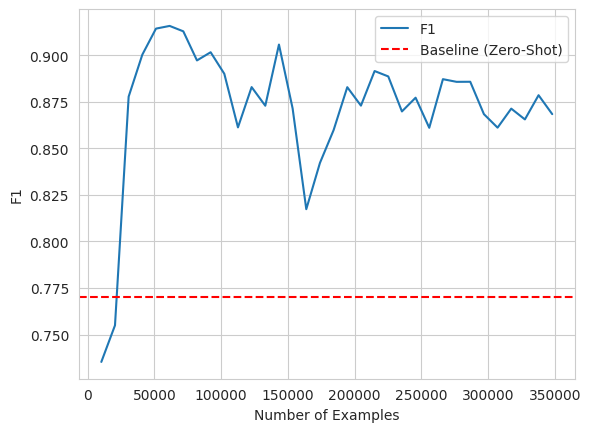

In [7]:
sns.set_style("whitegrid")
desired_metric = 'f1'
ax = sns.lineplot(data=metrics_df, x='examples', y=desired_metric, label=desired_metric.capitalize())
ax.set_xlabel('Number of Examples')
ax.set_ylabel(desired_metric.capitalize())
# adicionando uma linha com o valor de baseline
baseline_value = 0.77  # substitua pelo valor real do baseline
ax.axhline(baseline_value, color='red', linestyle='--', label='Baseline (Zero-Shot)')
ax.legend()
plt.show()

# Visualizando losses

In [8]:
import numpy as np

def show_losses(graph_df: pd.DataFrame, bs: int = 1024, title: str = "Losses", log_scale: bool = False) -> None:
    # filtrando valores de loss e eval_loss
    train_losses = graph_df['loss']
    loss_idx = ~train_losses.isna()
    train_losses = train_losses[loss_idx].tolist()
    train_steps = graph_df[loss_idx]['step'].tolist()
    val_losses = graph_df['eval_loss']
    loss_idx = ~val_losses.isna()
    val_losses = val_losses[loss_idx].tolist()
    val_steps = graph_df[loss_idx]['step'].tolist()

    all_losses = train_losses + val_losses

    if log_scale:
        all_losses = np.log(all_losses)

    iters = train_steps + val_steps
    iters = [i * bs for i in iters]  # multiplicando por bs para representar o numero de exemplos 

    labels = ["Train"] * len(train_losses) + ["Validation"] * len(val_losses) 
    plt.title(title)
    sns.lineplot(x=iters, y=all_losses, hue=labels, palette=["blue", "orange"])
    plt.show()



In [9]:
losses_logs = json.load(open(LOSSES_PATH, "r"))
losses_df = pd.DataFrame(losses_logs['log_history'])

In [10]:
losses_df

,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.001472,23.775700,0.000000e+00,4.8187,1,NaN,NaN,NaN,NaN
1,0.002944,23.701141,2.898551e-06,4.7965,2,NaN,NaN,NaN,NaN
2,0.004417,23.645510,5.797101e-06,4.7584,3,NaN,NaN,NaN,NaN
3,0.005889,23.431042,8.695652e-06,4.6634,4,NaN,NaN,NaN,NaN
4,0.007361,22.383310,1.159420e-05,4.4433,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
709,0.996688,0.041794,1.309329e-06,0.0014,677,NaN,NaN,NaN,NaN
710,0.998160,0.048669,9.819967e-07,0.0035,678,NaN,NaN,NaN,NaN
711,0.999632,0.023056,6.546645e-07,0.0018,679,NaN,NaN,NaN,NaN
712,1.000000,0.015438,3.273322e-07,0.0004,680,NaN,NaN,NaN,NaN


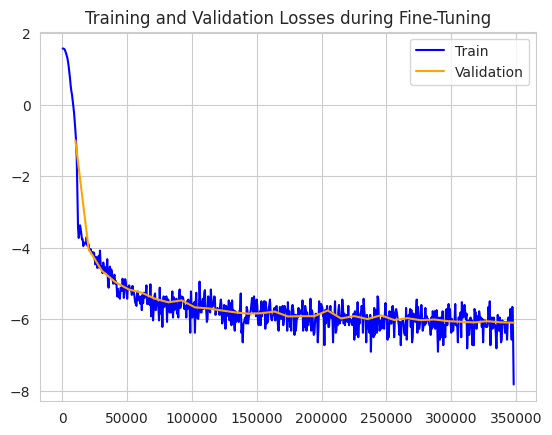

In [13]:
show_losses(losses_df,  bs=FINAL_BS, title="Training and Validation Losses during Fine-Tuning", log_scale=True)